# t-SNE (T-Distributed Stochastic Neighbor Embedding)
- It is a dimensionality reduction technique, and it’s particularly well suited for the visualization of high-dimensional data sets.
- Unlike PCA, its a **probabilistic** in nature. 
- We will use the Modified National Institute of Standards and Technology (MNIST) data set.  It is high dimensional dataset having **784 features/dimensions**
- We will reduce it to **< 100 features/dimensions**

In [2]:
import time

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import seaborn as sns

# Load dataset

In [3]:
# NOTE: This took 10 seconds
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

In [4]:
# shape of feature,target:  rows, columns
print(X.shape, y.shape) 

(70000, 784) (70000,)


In [5]:
# Lets print 1st data and its label. The 1st data is 1D array

np.set_printoptions(linewidth=115)

print("1st record of X:\n", X[0])
print("#################################")
print("1st label of y:", y[0])

1st record of X:
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
   0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
   0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
   0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0  

### The numerical values of pixel represent the gray scale number ranging from 0 - 255. There are 784 pixels in this data. 

# Plot

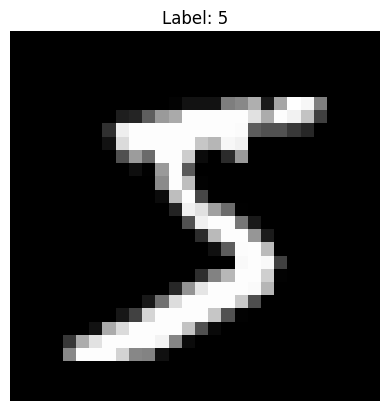

In [9]:
# Take the first image (row 0)
first_image = X[0]

# Reshape from (784,) to (28, 28)
image_28x28 = first_image.reshape(28, 28)

# Plot
plt.imshow(image_28x28, cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

## Normalize
- make all values between 0 and 1

In [20]:
# normalize the features
X = X / 255.0 

print("1st record of X:\n", X[0])

1st record of X:
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.        

# Prettify by making a dataframe
Lets make feature names as pixel0, pixel1, pixel2, ...


In [21]:
# 1) create columns
feat_cols = []
for i in range(X.shape[1]):
    feat_cols.append('pixel'+ str(i))

# feat_cols = [ 'pixel'+ str(i) for i in range(X.shape[1]) ]

print("features:", feat_cols)

features: ['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12', 'pixel13', 'pixel14', 'pixel15', 'pixel16', 'pixel17', 'pixel18', 'pixel19', 'pixel20', 'pixel21', 'pixel22', 'pixel23', 'pixel24', 'pixel25', 'pixel26', 'pixel27', 'pixel28', 'pixel29', 'pixel30', 'pixel31', 'pixel32', 'pixel33', 'pixel34', 'pixel35', 'pixel36', 'pixel37', 'pixel38', 'pixel39', 'pixel40', 'pixel41', 'pixel42', 'pixel43', 'pixel44', 'pixel45', 'pixel46', 'pixel47', 'pixel48', 'pixel49', 'pixel50', 'pixel51', 'pixel52', 'pixel53', 'pixel54', 'pixel55', 'pixel56', 'pixel57', 'pixel58', 'pixel59', 'pixel60', 'pixel61', 'pixel62', 'pixel63', 'pixel64', 'pixel65', 'pixel66', 'pixel67', 'pixel68', 'pixel69', 'pixel70', 'pixel71', 'pixel72', 'pixel73', 'pixel74', 'pixel75', 'pixel76', 'pixel77', 'pixel78', 'pixel79', 'pixel80', 'pixel81', 'pixel82', 'pixel83', 'pixel84', 'pixel85', 'pixel86', 'pixel87', 'pixel88', 'pixel89', 'pixel90'

In [22]:
# 2) Create a dataframe

df = pd.DataFrame(X, columns=feat_cols)
df['y'] = y
df["y"] = df["y"].astype(int)

X, y = None, None # lets free space

print('Size of the dataframe: {df.shape}')

print(df[:3])

Size of the dataframe: (70000, 785)
   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     0.0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
1     0.0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
2     0.0  ...       0.0       0.0       0.0       0.0       0.0       0.0   

   pixel781  pixel782  pixel783  y  
0       0.0       0.0       0.0  5  
1       0.0       0.0       0.0  0  
2       0.0       0.0       0.0  4  

[3 rows x 785 columns]


In [23]:
# 3) Lets look at the stats

print(df.describe())
print("%%%%%%%%%%%%%%%%%%%%")
print(df.info())

        pixel0   pixel1   pixel2   pixel3   pixel4   pixel5   pixel6   pixel7  \
count  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0   
mean       0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
std        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
25%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
50%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
75%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
max        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

        pixel8   pixel9  ...      pixel775      pixel776      pixel777  \
count  70000.0  70000.0  ...  70000.000000  70000.000000  70000.000000   
mean       0.0      0.0  ...      0.000390      0.000183      0.000065   
std        0.0      0.0  ...      0.016691      

## SIDE NOTE:
- If you notice, you will see that entries in pixel0, pixel1, pixel2,..,pixel9 are all 0.
- If we know that these columns will always contain same value, we can safely drop these columns that contains same value.
- **In this case I will keep it.**

## Randomization

We’ll take a random subset of the digits because we don’t want to be using 70,000 digits in our calculations. The randomization is important as the data set is sorted by its y label (i.e., the first 7,000 or so are zeros, etc.). 

We’ll create a random permutation of the numbers zero to 69,999 to ensure randomization. This allows us to select the first 5-to-10,000 for our calculations and visualizations.

In [1]:
import numpy as np

random_perm = np.random.permutation(10)
print(random_perm)

[6 8 9 1 4 2 3 5 7 0]


In [25]:
# 1) Lets create random set of column indexes

# For reproducability of the results
np.random.seed(42)

# random_perm = np.random.permutation(10) 
random_perm = np.random.permutation(df.shape[0]) # 70000 random index from 0 to 69,999

print(random_perm)

[46730 48393 41416 ... 54886   860 15795]


<Figure size 640x480 with 0 Axes>

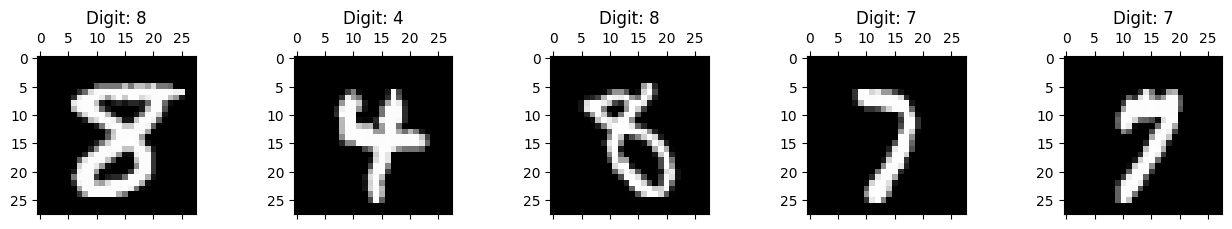

In [26]:
# 2) We now have our DataFrame and our randomization vector. Now, we can check what these numbers actually look like

plt.gray()
fig = plt.figure( figsize=(16,7) )
for i in range(0,5):
    digit_label = str(df.loc[random_perm[i],'y'])
    ax = fig.add_subplot(3,5,i+1, title=f"Digit: {digit_label}" )
    ax.matshow(df.loc[random_perm[i],feat_cols].values.reshape((28,28)).astype(float))
    
plt.show()

## Lets apply PCA first
PCA is a technique used to reduce the number of dimensions in a data set while retaining the most information. It uses the correlation between some dimensions and tries to provide a minimum number of variables that keeps the maximum amount of variation or information about how the original data is distributed. 

Since we like our two- and three-dimensional plots, let’s start with that and generate from the original 784 dimensions, the first three principal components. We’ll also see how much of the variation in the total data set they actually account for.

In [27]:
# 1) Lets reduce to 3D

pca = PCA(n_components=3)

# Fit PCA on the feature data
pca.fit(df[feat_cols].values)

# Transform the data using learned components
pca_result = pca.transform(df[feat_cols].values)

# pca_result = pca.fit_transform(df[feat_cols].values) # or combine above 2

df['pca-1'] = pca_result[:,0]
df['pca-2'] = pca_result[:,1] 
df['pca-3'] = pca_result[:,2]

print(f'Explained variation per principal component: {pca.explained_variance_ratio_}')

# Explained variation per principal component: [0.09746116 0.07155445 0.06149531]

Explained variation per principal component: [0.09746116 0.07155445 0.06149531]


Given that the first two components account for about (0.1 + 0.7= 0.17 ) 17 percent of the variation in the entire data set, let’s see if that is enough to visually set the different digits apart. We can create a scatterplot of the first and second principal component and color each of the different types of digits with a different color. If we are lucky, the same type of digits will be positioned, or  clustered, together in groups. This would mean that the first two principal components actually tell us a great deal about the specific types of digits.

<Axes: xlabel='pca-1', ylabel='pca-2'>

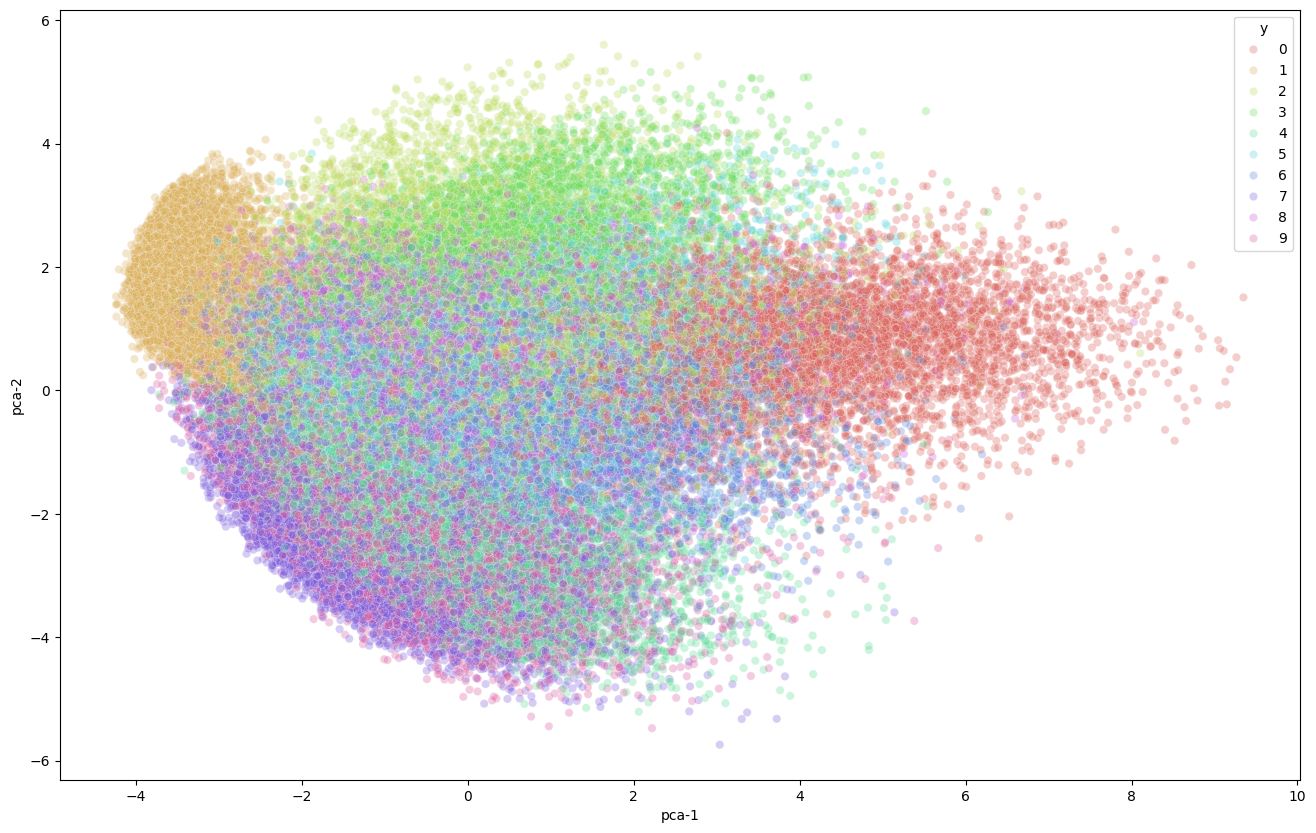

In [28]:
# 2) 2D plot the above pc: Took 4 seconds

plt.figure(figsize=(16,10))
sns.scatterplot(
    x="pca-1", y="pca-2",
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df.loc[random_perm,:],
    legend="full",
    alpha=0.3
)

We can see the two components definitely hold some information, especially for specific digits. But it’s not enough to set all of them apart. 

Now lets plot above using first 3 principle components and see if it helps

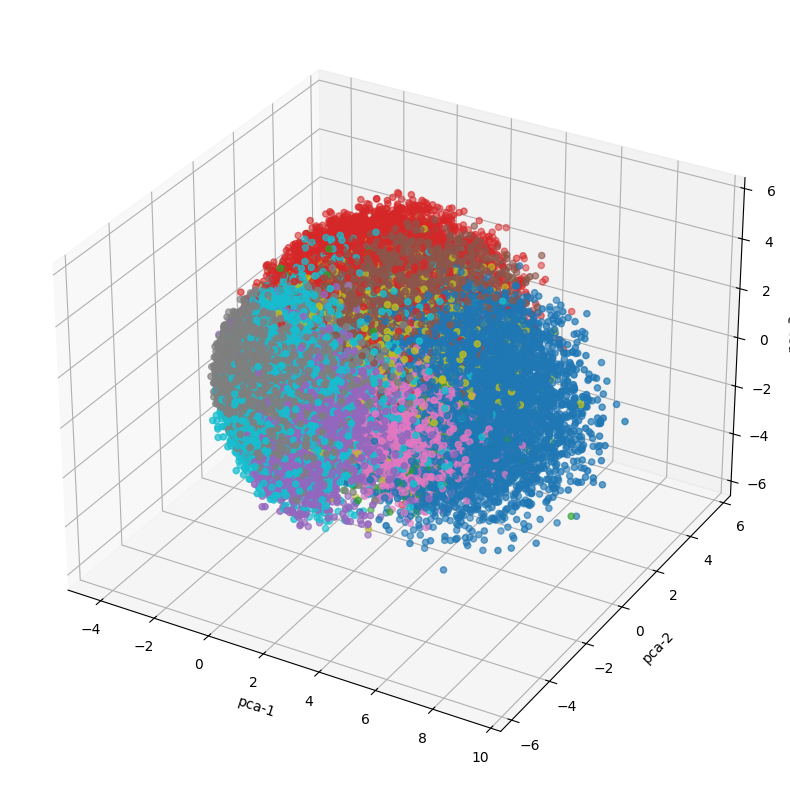

In [29]:
# 3) 3 Dimension

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')  # Correct way to create a 3D plot

ax.scatter(
    xs=df.loc[random_perm,:]["pca-1"], 
    ys=df.loc[random_perm,:]["pca-2"], 
    zs=df.loc[random_perm,:]["pca-3"], 
    c=df.loc[random_perm,:]["y"], 
    cmap='tab10'
)
ax.set_xlabel('pca-1')
ax.set_ylabel('pca-2')
ax.set_zlabel('pca-3')
plt.show()

# Optional
Lets plot above using plotly for different visuals

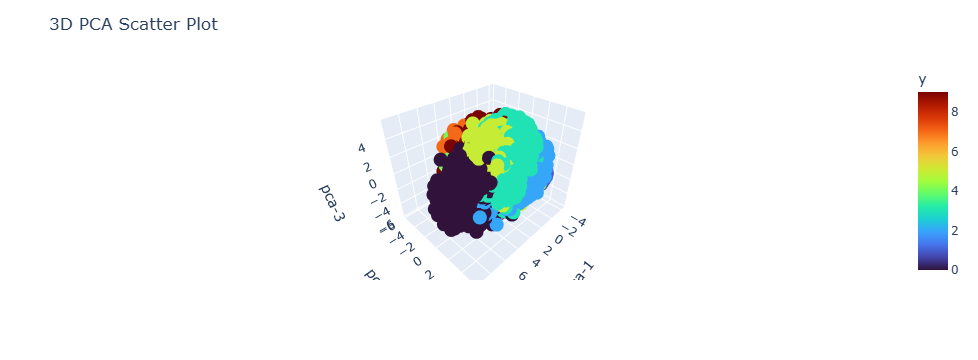

In [30]:
# (SKIP) OPTIONAL. Uses plotly
import plotly.express as px # have to install plotly

fig = px.scatter_3d(
    df.loc[random_perm, :], 
    x='pca-1', 
    y='pca-2', 
    z='pca-3', 
    color='y',  # Color based on 'y' column
    color_continuous_scale='turbo'  # Similar to 'tab10'
)

fig.update_layout(
    scene=dict(
        xaxis_title='pca-1',
        yaxis_title='pca-2',
        zaxis_title='pca-3'
    ),
    title='3D PCA Scatter Plot'
)

fig.show()

## t-SNE

### Lets work on smaller dataset: 10000 images

we will first try to run the t-SNE algorithm on the actual dimensions of the data (784) and see how it does. We’ll only use the first 10,000 samples to run the algorithm on to make sure we don’t burden our machine in terms of **memory, power and time**.

Lets run the PCA again on this 10000 subset to compare.

In [31]:
# 1) PCA first
N = 10000

df_subset = df.loc[random_perm[:N],:].copy()

data_subset = df_subset[feat_cols].values

pca = PCA(n_components=3)
# Fit PCA on the feature data
pca.fit(data_subset)

# Transform the data using learned components
pca_result = pca.transform(data_subset)

# pca_result = pca.fit_transform(data_subset) # or combine both above

df_subset['pca-1'] = pca_result[:,0]
df_subset['pca-2'] = pca_result[:,1] 
df_subset['pca-3'] = pca_result[:,2]

print(f'Explained variation per principal component: {pca.explained_variance_ratio_}'

# [out] Explained variation per principal component: [0.09730166 0.07135901 0.06183721]

Explained variation per principal component: [0.09819946 0.07123677 0.06113222]


In [32]:
# 2) t-SNE next: Took 69 seconds

time_start = time.process_time()
tsne = TSNE(n_components=2, verbose=1, perplexity=40, max_iter=300)
tsne_results = tsne.fit_transform(data_subset)
time_end = time.process_time()

print(f"t-SNE done! Time elapsed: {time_end - time_start} seconds")

# [out] [t-SNE] Computing 121 nearest neighbors...
# [t-SNE] Indexed 10000 samples in 0.564s...
# [t-SNE] Computed neighbors for 10000 samples in 121.191s...
# [t-SNE] Computed conditional probabilities for sample 1000 / 10000
# [t-SNE] Computed conditional probabilities for sample 2000 / 10000
# [t-SNE] Computed conditional probabilities for sample 3000 / 10000
# [t-SNE] Computed conditional probabilities for sample 4000 / 10000
# [t-SNE] Computed conditional probabilities for sample 5000 / 10000
# [t-SNE] Computed conditional probabilities for sample 6000 / 10000
# [t-SNE] Computed conditional probabilities for sample 7000 / 10000
# [t-SNE] Computed conditional probabilities for sample 8000 / 10000
# [t-SNE] Computed conditional probabilities for sample 9000 / 10000
# [t-SNE] Computed conditional probabilities for sample 10000 / 10000
# [t-SNE] Mean sigma: 2.129023
# [t-SNE] KL divergence after 250 iterations with early exaggeration: 85.957787
# [t-SNE] KL divergence after 300 iterations: 2.823509
# t-SNE done! Time elapsed: 157.3975932598114 seconds

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.043s...
[t-SNE] Computed neighbors for 10000 samples in 4.567s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 2.117974
[t-SNE] KL divergence after 250 iterations with early exaggeration: 85.847946
[t-SNE] KL divergence after 300 iterations: 2.770907
t-SNE done! Time elapsed:

Now that we have the two resulting dimensions, we can create a scatter plot of the two dimensions and color each sample by its respective label to visualize them.

<Axes: xlabel='tsne-2d-one', ylabel='tsne-2d-two'>

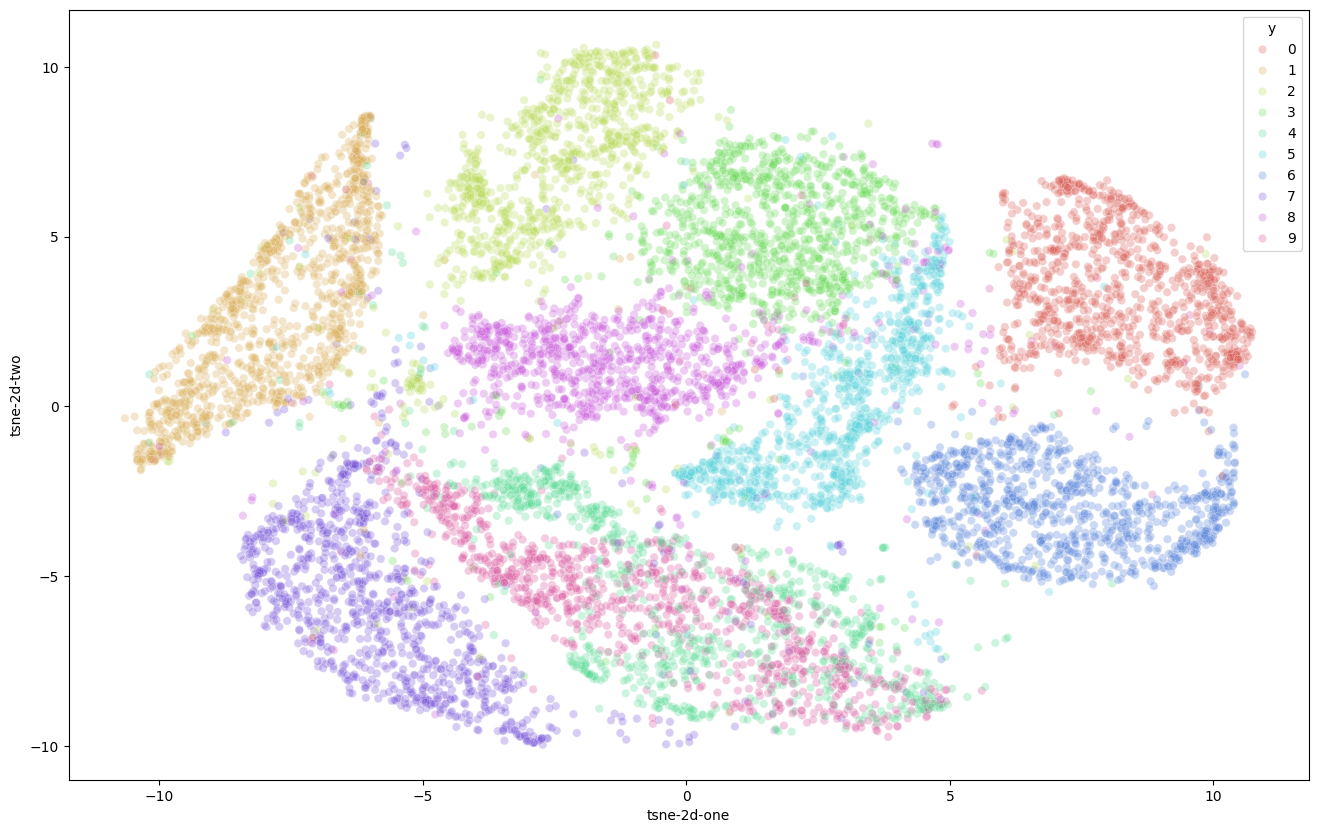

In [33]:
# 3) Plot
df_subset['tsne-2d-one'] = tsne_results[:,0]
df_subset['tsne-2d-two'] = tsne_results[:,1]

plt.figure(figsize=(16,10))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df_subset,
    legend="full",
    alpha=0.3
)

## PCA vs t-SNE 

<Axes: xlabel='tsne-2d-one', ylabel='tsne-2d-two'>

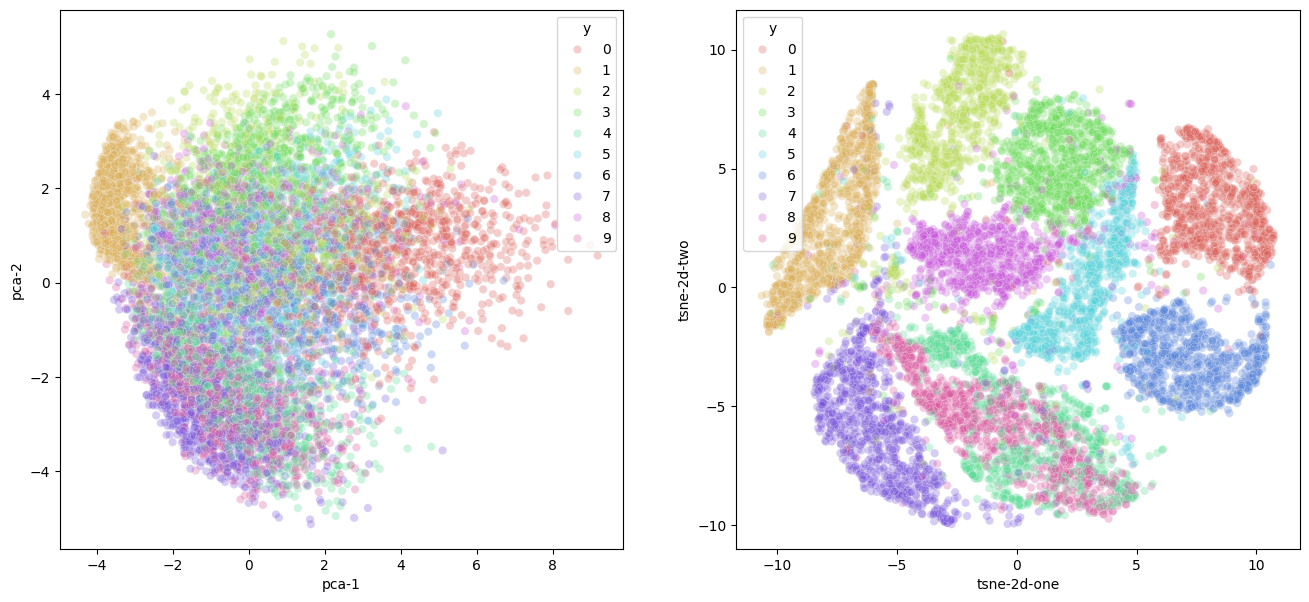

In [34]:
# 4)
plt.figure(figsize=(16,7))

ax1 = plt.subplot(1, 2, 1)
sns.scatterplot(
    x="pca-1", y="pca-2",
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df_subset,
    legend="full",
    alpha=0.3,
    ax=ax1
)

ax2 = plt.subplot(1, 2, 2)
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df_subset,
    legend="full",
    alpha=0.3,
    ax=ax2
)

## Combine PCA with t-SNE
- **X(784 features) --> Apply PCA to X (50 features) --> Apply t-SNE (2 features)**

In [36]:
# 1) X (784 features) --> X_pca (50 features) 
X_pca_50 = PCA(n_components=50)

# Fit PCA on the data
X_pca_50.fit(data_subset)

# Transform the data using the fitted PCA
pca_result_50 = X_pca_50.transform(data_subset)

# Or do it in 1 single shot
# pca_result_50 = X_pca_50.fit_transform(data_subset)


cum_var = np.sum(X_pca_50.explained_variance_ratio_)
print(f"Cumulative explained variation for 50 principal components: {cum_var}")

# [out] Cumulative explained variation for 50 principal components: 0.8262

Cumulative explained variation for 50 principal components: 0.8262021893487207


In [37]:
# 2) NOTE: It took 69 seconds 
# Apply PCA to X (50 features) --> Apply t-SNE (2 features)

time_start = time.process_time()
tsne = TSNE(n_components=2, verbose=1, perplexity=40, max_iter=300)
tsne_pca_results = tsne.fit_transform(pca_result_50)
time_end = time.process_time()

print(f"t-SNE done! Time elapsed: {time_end - time_start} seconds")

# [out] t-SNE done! Time elapsed: 42.01495909690857 seconds

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.002s...
[t-SNE] Computed neighbors for 10000 samples in 0.447s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 1.829852
[t-SNE] KL divergence after 250 iterations with early exaggeration: 84.796127
[t-SNE] KL divergence after 300 iterations: 2.752077
t-SNE done! Time elapsed:

This is a significant improvement over the PCA visualization we used earlier. We can see that the digits are very clearly clustered in their own sub groups. 

**If we used a clustering algorithm to pick out the separate clusters, we could probably quite accurately assign new points to a label**

 ### Lets compare PCA,t-SNE and PCA+t-SNE side by side:

<Axes: xlabel='tsne-pca50-one', ylabel='tsne-pca50-two'>

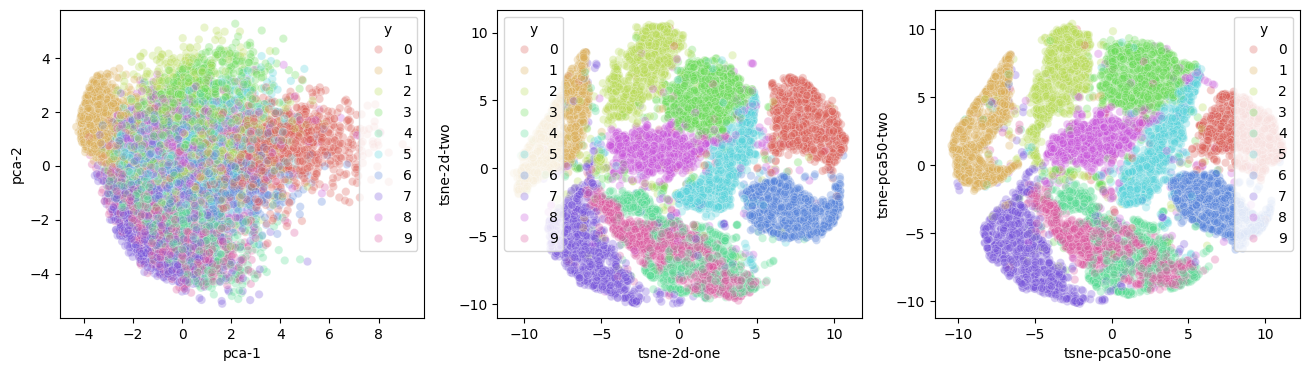

In [38]:
# 3)
df_subset['tsne-pca50-1'] = tsne_pca_results[:,0]
df_subset['tsne-pca50-2'] = tsne_pca_results[:,1]


plt.figure(figsize=(16,4))
ax1 = plt.subplot(1, 3, 1)
sns.scatterplot(
    x="pca-1", y="pca-2",
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df_subset,
    legend="full",
    alpha=0.3,
    ax=ax1
)

ax2 = plt.subplot(1, 3, 2)
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df_subset,
    legend="full",
    alpha=0.3,
    ax=ax2
)

ax3 = plt.subplot(1, 3, 3)
sns.scatterplot(
    x="tsne-pca50-one", y="tsne-pca50-two",
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df_subset,
    legend="full",
    alpha=0.3,
    ax=ax3
)

# What now ?
- Going forward, you can now discard original dataset with 784 features and work with only 2 features to design ML model, etc